# Hermite Polynomials

Hermite polynomials are a sequence of polynomials that commonly arise in problems involving the Gaussian function. They are denoted by $H_n(x)$, where $n$ is the polynomial degree. The first few physicist's Hermite polynomials are

$$
H_0(x) = 1,\quad
H_1(x) = 2x,\quad
H_2(x) = 4x^2-2,\quad
H_3(x) = 8x^3-12x.
$$

Hermite polynomials are orthogonal on $(-\infty,\infty)$ with respect to the weight function $e^{-x^2}$:

$$
\int_{-\infty}^{\infty}\frac{e^{-x^2}}{\sqrt{\pi}}H_m(x)H_n(x)\,dx = 2^n n!\,\delta_{mn}.
$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Hermite
from math import factorial, sqrt

In [7]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Quantum Harmonic Oscillator

Hermite polynomials appear naturally in the one-dimensional quantum harmonic oscillator. Starting from the time-independent Schrödinger equation,

$$
\left[-\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x)\right]\Psi(x) = E\Psi(x),
$$

consider the harmonic oscillator potential

$$
V(x) = \frac{1}{2}m\omega^2x^2.
$$

Using dimensionless coordinates and natural units such that

$$
\hbar = m = \omega = 1,
$$

the Schrödinger equation becomes

$$
\left[-\frac{1}{2}\frac{d^2}{dx^2} + \frac{x^2}{2}\right]\Psi(x) = E\Psi(x).
$$

This is an eigenvalue problem: the allowed energies $E_n$ are the eigenvalues, while the corresponding stationary states $\Psi_n(x)$ are the eigenfunctions.

The normalized solutions can be written in terms of Hermite polynomials as

$$
\Psi_n(x) = \frac{1}{\pi^{1/4}\sqrt{2^n n!}}e^{-x^2/2}H_n(x).
$$

The Hermite polynomial determines the polynomial structure of the wavefunction, while the Gaussian factor

$$
e^{-x^2/2}
$$

provides its overall spatial envelope.

The corresponding energy eigenvalues are

$$
E_n = n + \frac{1}{2},\quad
n = 0, 1, 2, \ldots
$$

in the chosen natural units. The integer $n$ labels the energy eigenstates. As $n$ increases, the degree of the Hermite polynomial increases, introducing additional nodes into the wavefunction. The normalization factor ensures that each stationary state satisfies

$$
\int_{-\infty}^{\infty}|\Psi_n(x)|^2\,dx = 1.
$$

Thus, the Hermite polynomial is not introduced independently of the physical problem: it emerges directly from solving the Schrödinger equation for the harmonic oscillator potential.

Using NumPy's `Hermite`, the polynomial $H_n(x)$ can be constructed by setting the coefficient of the $n$-th Hermite basis function to one `Hermite([0] * n + [1])`. The normalized wavefunction can then be evaluated as:

In [8]:
psi = lambda n, x: 1 / sqrt((2**n) * factorial(n) * sqrt(np.pi)) * np.exp(-x**2 / 2) * Hermite([0]*n + [1])(x)

The first four stationary states, $n = 0, 1, 2, 3$, can be evaluated and plotted over the interval $[-5,5]$.

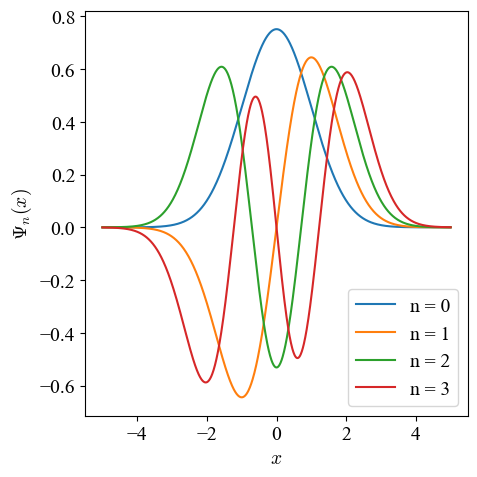

In [9]:
x = np.linspace(-5, 5, 1000)
plt.figure(figsize=(5, 5))
for n in range(4):
    plt.plot(x, psi(n, x), label=f'n = {n}')
plt.xlabel(r"$x$")
plt.ylabel(r"$\Psi_n(x)$")
plt.legend()
plt.tight_layout()
plt.show()